# 🧠 The Mechanics of a Perceptron

Welcome to the "Under the Hood" session. 

In the previous lesson, we treated the Neural Network as a black box that magically classifies digits. Today, we will break that box open. We will simplify the problem to **2 dimensions** so we can visualize exactly what the mathematics is doing.

### Goals:
1.  **The Bias Intuition:** Why do we need that `+ b` in $wx + b$?
2.  **Manual Gradient Descent:** We will train a neuron *by hand* (without PyTorch's magic) to see how weights update pixel-by-pixel.
3.  **The Power of Non-Linearity:** Why stacking linear layers is useless without activation functions.
4.  **PyTorch Implementation:** Doing it the easy way.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from IPython.display import clear_output

# Configuration for cleaner plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## Part 1: The Mystery of Bias ($b$)

A single neuron performs a linear operation: $z = w_1 x_1 + w_2 x_2 + b$.
This creates a line that separates the plane.

But why do we need $b$? Can't we just use $w_1 x_1 + w_2 x_2$?

Let's look at two scenarios.

### Scenario A: The "Lucky" Seed (No Bias Needed)
We generate data using `random_state=9`.

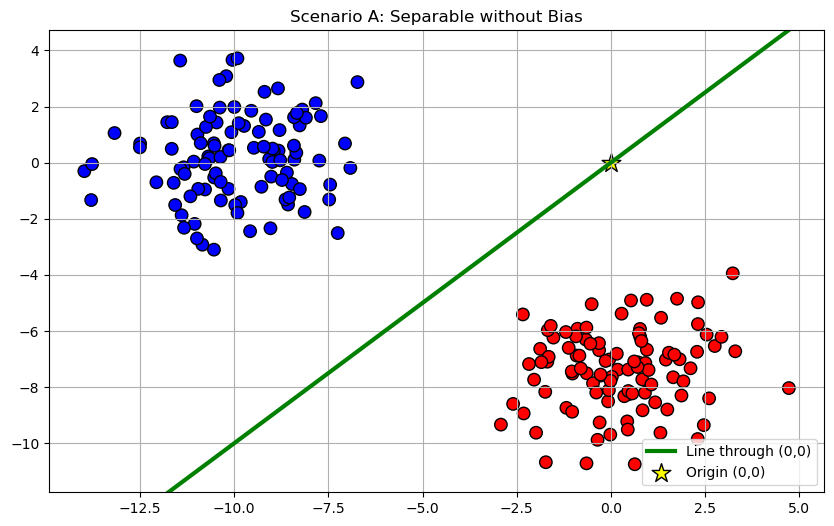

In [2]:
# Generate data centered roughly around the origin or separable by a line through origin
X_np, y_np = make_blobs(n_samples=200, centers=2, n_features=2, random_state=9, cluster_std=1.5)
X = torch.FloatTensor(X_np)
y = torch.FloatTensor(y_np).reshape(-1, 1)

# Helper function to plot lines
def plot_line_through_origin(w1, w2, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=80)
    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    # Line through origin: w1*x1 + w2*x2 = 0  =>  x2 = -(w1/w2)*x1
    if w2 != 0:
        y_vals = -(w1 / w2) * x_vals
        plt.plot(x_vals, y_vals, 'g-', linewidth=3, label="Line through (0,0)")
    plt.scatter(0, 0, c='yellow', s=200, edgecolors='black', marker='*', label="Origin (0,0)")
    plt.title(title)
    plt.legend()
    plt.ylim(X[:, 1].min()-1, X[:, 1].max()+1)
    plt.show()

# Here, a line passing through (0,0) CAN separate the data
plot_line_through_origin(1.0, -1.0, X, y, "Scenario A: Separable without Bias")

### Scenario B: The "Real" World (Bias Required)
Now we use `random_state=17`. The clouds are shifted.

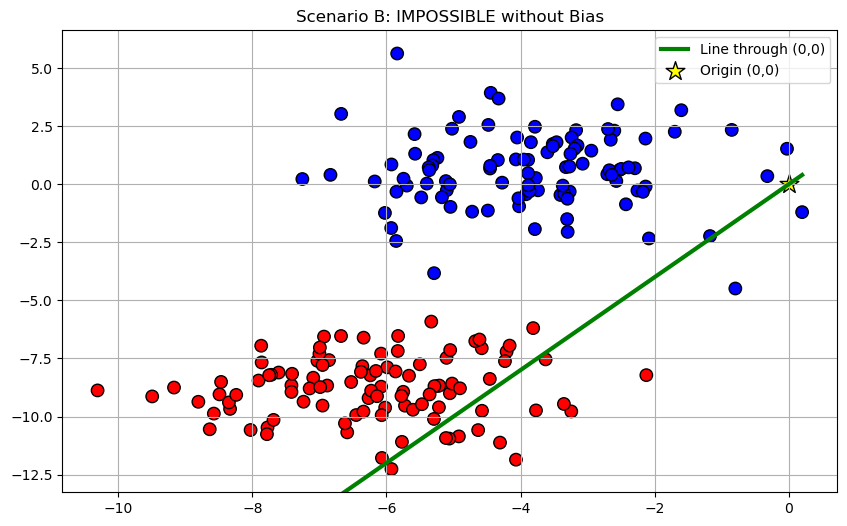

In [3]:
X_np, y_np = make_blobs(n_samples=200, centers=2, n_features=2, random_state=17, cluster_std=1.5)
X = torch.FloatTensor(X_np)
y = torch.FloatTensor(y_np).reshape(-1, 1)

# Try to separate this with a line stuck at (0,0)
plot_line_through_origin(1.0, -0.5, X, y, "Scenario B: IMPOSSIBLE without Bias")

**Observation:** In Scenario B, no matter how much you rotate the green line, you cannot perfectly separate Red from Blue. The line is "pinned" to the star at (0,0).

**The Solution:** Adding **Bias ($b$)** unpins the line. It allows the line to slide left, right, up, or down. 

$$ w_1 x_1 + w_2 x_2 + b = 0 $$

## Part 2: Manual Gradient Descent (With Sigmoid)

Now we will train the neuron **manually**, without using PyTorch's `autograd`. We will use the **Sigmoid** activation function.

### The Math: Forward Pass
1.  **Linear Step:** $z = w_1 x_1 + w_2 x_2 + b$
2.  **Activation:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$

### The Math: Backward Pass (Deriving the Gradient)
We want to update weights to minimize the **Binary Cross Entropy Loss**:
$$ L = -[y_{true} \log(\hat{y}) + (1-y_{true}) \log(1-\hat{y})] $$

To find the gradient $\frac{\partial L}{\partial w}$, we apply the **Chain Rule**:
$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w} $$

Let's break it down step-by-step:

1.  **Derivative of Loss w.r.t Prediction:** 
    $$ \frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y_{true}}{\hat{y}(1 - \hat{y})} $$

2.  **Derivative of Sigmoid w.r.t Linear Input:** 
    $$ \frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \hat{y}(1 - \hat{y}) $$

3.  **Derivative of Linear Input w.r.t Weight:** 
    $$ \frac{\partial z}{\partial w} = x $$

**The "Magic" Cancellation:**
When we multiply step (1) and step (2), the denominator cancels out with the numerator:
$$ \frac{\partial L}{\partial z} = \left( \frac{\hat{y} - y_{true}}{\hat{y}(1 - \hat{y})} \right) \cdot \left( \hat{y}(1 - \hat{y}) \right) = (\hat{y} - y_{true}) $$

So the Final Gradient is simply:
$$ \frac{\partial L}{\partial w} = (\hat{y} - y_{true}) \cdot x $$

### The Update Rule
$$ w_{new} = w_{old} - lr \cdot \underbrace{(\hat{y} - y_{true}) \cdot x}_{\text{Gradient}} $$

In [5]:
# Let's initialize random weights manually
w1 = 0.5
w2 = -0.5
b = 0.0
lr = 0.01 # Learning Rate (Size of the step)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(f"--- INITIAL STATE ---")
print(f"Weights: w1={w1}, w2={w2}")
print(f"Bias:    b={b}")

# --- STEP-BY-STEP DEMO ON 3 POINTS ---
print("\n=============================================")
print("         MANUAL TRAINING STARTING")
print("=============================================")

for i in range(3):
    print(f"\n--- SAMPLE {i+1} ---")
    
    # 1. Get one sample
    x_sample = X_np[i]
    y_true = y_np[i]
    print(f"1. Input x: [{x_sample[0]:.2f}, {x_sample[1]:.2f}] | True Label y: {y_true}")
    
    # 2. Forward Pass
    z = w1 * x_sample[0] + w2 * x_sample[1] + b
    print(f"2. Linear Sum z = ({w1:.2f} * {x_sample[0]:.2f}) + ({w2:.2f} * {x_sample[1]:.2f}) + {b:.2f} = {z:.4f}")
    
    y_pred = sigmoid(z)
    print(f"3. Activation (Sigmoid) y_pred = 1 / (1 + e^-{z:.4f}) = {y_pred:.4f}")
    
    # 3. Calculate Error
    error = y_pred - y_true
    print(f"4. Error = Prediction - True = {y_pred:.4f} - {y_true} = {error:.4f}")
    
    # 4. Calculate Gradients (How much did each weight contribute to the error?)
    w1_grad = error * x_sample[0]
    w2_grad = error * x_sample[1]
    b_grad = error * 1.0
    
    print(f"5. Gradients (Backprop):")
    print(f"   dL/dw1 = Error * x1 = {error:.4f} * {x_sample[0]:.2f} = {w1_grad:.4f}")
    print(f"   dL/dw2 = Error * x2 = {error:.4f} * {x_sample[1]:.2f} = {w2_grad:.4f}")
    print(f"   dL/db  = Error * 1  = {b_grad:.4f}")
    
    # 5. Update Weights
    w1 = w1 - lr * w1_grad
    w2 = w2 - lr * w2_grad
    b  = b  - lr * b_grad
    
    print(f"6. Update (lr={lr}):")
    print(f"   w1_new = w1_old - lr * grad = {w1:.4f}")
    print(f"   w2_new = w2_old - lr * grad = {w2:.4f}")
    print(f"   b_new  = b_old  - lr * grad = {b:.4f}")
    print("---------------------------------------------")

--- INITIAL STATE ---
Weights: w1=0.5, w2=-0.5
Bias:    b=0.0

         MANUAL TRAINING STARTING

--- SAMPLE 1 ---
1. Input x: [-3.89, 1.05] | True Label y: 0
2. Linear Sum z = (0.50 * -3.89) + (-0.50 * 1.05) + 0.00 = -2.4685
3. Activation (Sigmoid) y_pred = 1 / (1 + e^--2.4685) = 0.0781
4. Error = Prediction - True = 0.0781 - 0 = 0.0781
5. Gradients (Backprop):
   dL/dw1 = Error * x1 = 0.0781 * -3.89 = -0.3035
   dL/dw2 = Error * x2 = 0.0781 * 1.05 = 0.0820
   dL/db  = Error * 1  = 0.0781
6. Update (lr=0.01):
   w1_new = w1_old - lr * grad = 0.5030
   w2_new = w2_old - lr * grad = -0.5008
   b_new  = b_old  - lr * grad = -0.0008
---------------------------------------------

--- SAMPLE 2 ---
1. Input x: [-8.33, -9.67] | True Label y: 1
2. Linear Sum z = (0.50 * -8.33) + (-0.50 * -9.67) + -0.00 = 0.6518
3. Activation (Sigmoid) y_pred = 1 / (1 + e^-0.6518) = 0.6574
4. Error = Prediction - True = 0.6574 - 1 = -0.3426
5. Gradients (Backprop):
   dL/dw1 = Error * x1 = -0.3426 * -8.33 = 2.8

### Visualizing the Learning Trajectory

Now let's run this loop over **all points** for multiple epochs.
We will visualize the **Decision Boundary** changing in real-time.

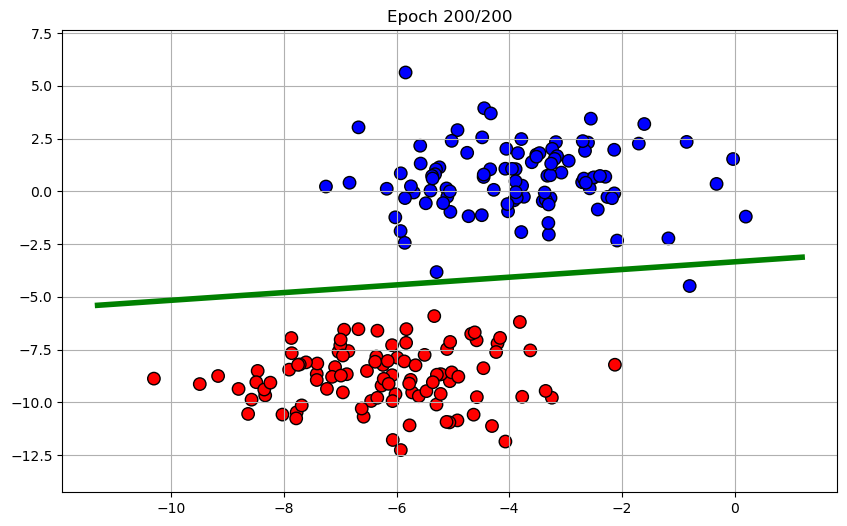

Training Finished!


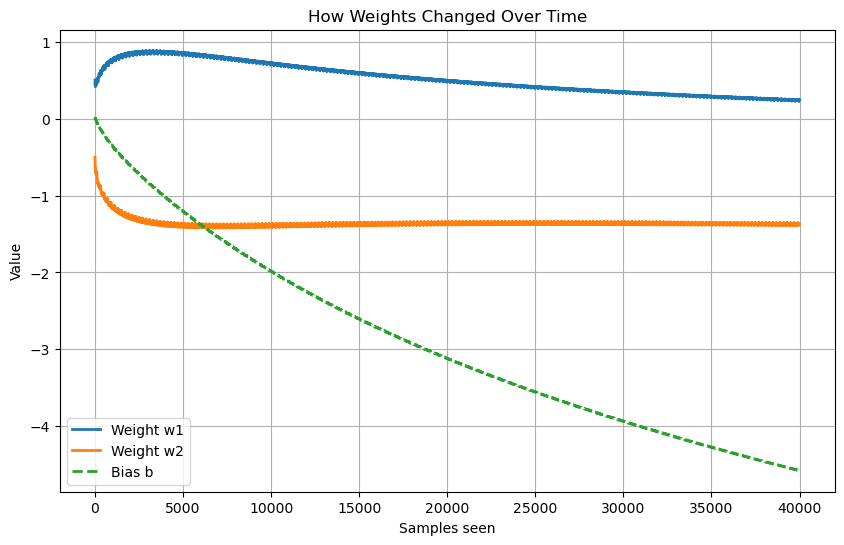

In [6]:
# Helper to draw the line
def plot_decision_boundary(w1, w2, b, X, y, title="Decision Boundary"):
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=80)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_vals = np.linspace(x1_min, x1_max, 100)
    if w2 != 0: 
        x2_vals = -(w1 * x1_vals + b) / w2
        plt.plot(x1_vals, x2_vals, 'g-', linewidth=4, label="Boundary")
    plt.title(title)
    plt.ylim(X[:, 1].min() - 2, X[:, 1].max() + 2)
    plt.show()

# Reset weights
w1, w2, b = 0.5, -0.5, 0.0
lr = 0.01
epochs = 200

# Lists to store history for plotting later
history_w1 = []
history_w2 = []
history_b = []

# Run Training Loop
for epoch in range(epochs):
    for i in range(len(X_np)):
        x_sample = X_np[i]
        y_true = y_np[i]
        
        # Forward
        z = w1 * x_sample[0] + w2 * x_sample[1] + b
        y_pred = sigmoid(z)
        
        # Update
        error = y_pred - y_true
        w1 -= lr * (error * x_sample[0])
        w2 -= lr * (error * x_sample[1])
        b  -= lr * (error * 1.0)
        
        # Record history
        history_w1.append(w1)
        history_w2.append(w2)
        history_b.append(b)
        
    # ANIMATION: Update plot once per epoch
    clear_output(wait=True)
    plot_decision_boundary(w1, w2, b, X, y, title=f"Epoch {epoch+1}/{epochs}")
    plt.pause(0.01)

print("Training Finished!")

# Plotting the journey on ONE graph
plt.figure(figsize=(10, 6))
plt.plot(history_w1, label="Weight w1", linewidth=2)
plt.plot(history_w2, label="Weight w2", linewidth=2)
plt.plot(history_b, label="Bias b", linewidth=2, linestyle="--")
plt.title("How Weights Changed Over Time")
plt.xlabel("Samples seen")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

### Important Concept: Error vs. Loss

You might wonder: "Why did we use `error = prediction - true`? Isn't there a complicated Loss function?"

1.  **Error:** This is simply the difference: how far off was my guess? 
    * Example: I guessed 0.8, Truth is 1.0. Error = -0.2.
    
2.  **Loss:** A Loss function (like Binary Cross Entropy) is a "Scorecard" that penalizes wrong answers exponentially.
    * However, due to the **Chain Rule of Calculus**, the Gradient of the BCE Loss with respect to the input $z$ simplifies beautifully to just `prediction - true`.
    
### Derivatives with Activation Functions (The Chain Rule)

When we use `y_pred = sigmoid(z)`, we are chaining functions:
Input $x$ $\to$ Linear $z$ $\to$ Activation $a$ $\to$ Loss $L$.

To find how to change weight $w$, we multiply derivatives backwards:

$$ \frac{\partial L}{\partial w} = \underbrace{\frac{\partial L}{\partial a}}_{(1)} \cdot \underbrace{\frac{\partial a}{\partial z}}_{(2)} \cdot \underbrace{\frac{\partial z}{\partial w}}_{(3)} $$

1.  **How Loss changes with Activation**
2.  **How Activation changes with Linear Sum** (Derivative of Sigmoid)
3.  **How Linear Sum changes with Weight** (Just $x$!)

For the specific combination of **BCE Loss + Sigmoid**, parts (1) and (2) cancel out to simply: $(\hat{y} - y)$. 
That is why our manual update `error * x` works!

## Part 3: Doing it in PyTorch

Now that you understand the math, let's see how PyTorch handles this.

### What is an Optimizer?
In our manual code, we updated weights simply: `w = w - lr * grad`.
An **Optimizer** (like SGD or Adam) is a specialized tool that handles this update step.

* **Analogy:** Imagine you are hiking down a mountain in the fog.
    * **The Gradient** tells you which way is "down".
    * **The Optimizer** decides **how big a step** to take. 
    * Smart optimizers (like Adam) also remember "momentum" (if you were running down fast, don't stop immediately).

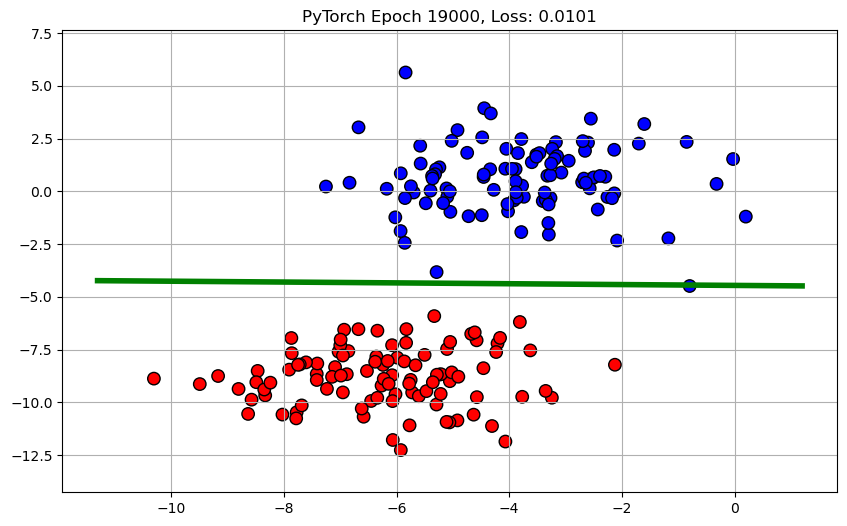

In [11]:
# 1. Model
model = nn.Sequential(
    nn.Linear(2, 1), 
    nn.Sigmoid()
)

# 2. Optimizer (Handles the w = w - lr * grad part)
optimizer = optim.SGD(model.parameters(), lr=0.05)

# 3. Loss
criterion = nn.BCELoss()

# Training Loop (PyTorch style) with Animation
epochs = 20000
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # ANIMATION: Update every 1000 epochs
    if epoch % 1000 == 0:
        # Extract weights from PyTorch model to plot
        w = model[0].weight.data.numpy()[0] # [w1, w2]
        b = model[0].bias.data.numpy()[0]   # b
        
        clear_output(wait=True)
        plot_decision_boundary(w[0], w[1], b, X, y, 
                             title=f"PyTorch Epoch {epoch}, Loss: {loss.item():.4f}")
        plt.pause(0.1)

## Part 4: The Limitation of Linearity

Now let's try the "Moons" dataset, which is NOT linearly separable.

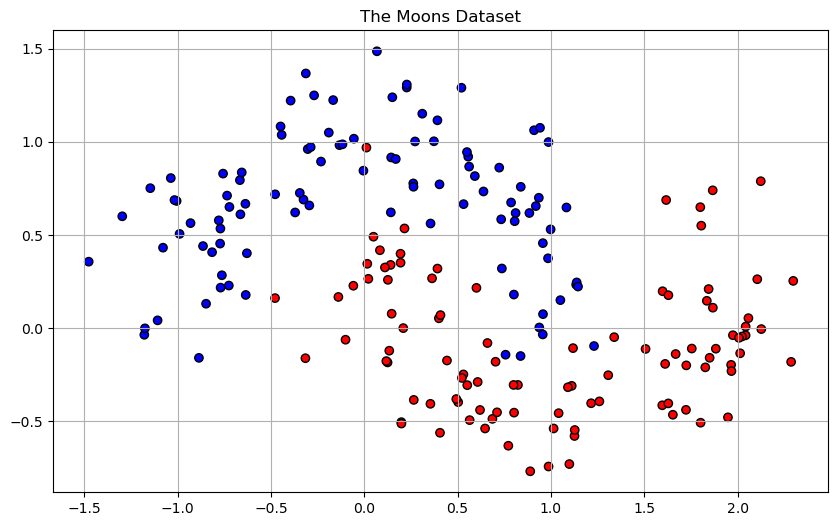

In [13]:
X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)
X_m = torch.FloatTensor(X_moon)
y_m = torch.FloatTensor(y_moon).reshape(-1, 1)

plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m[:, 0], cmap='bwr', edgecolors='k')
plt.title("The Moons Dataset")
plt.show()

### Experiment 1: Deep Linear Network (No hidden activations, only linear layers; sigmoid only at output)

What if we stack many layers, but **forget** the activation functions (ReLU)?
$$ y = W_2(W_1 x + b_1) + b_2 $$
Mathematically, this simplifies to just one big linear layer: $y = W_{new} x + b_{new}$.

**Let's watch the training. The model will TRY to bend the line, but it will fail.**

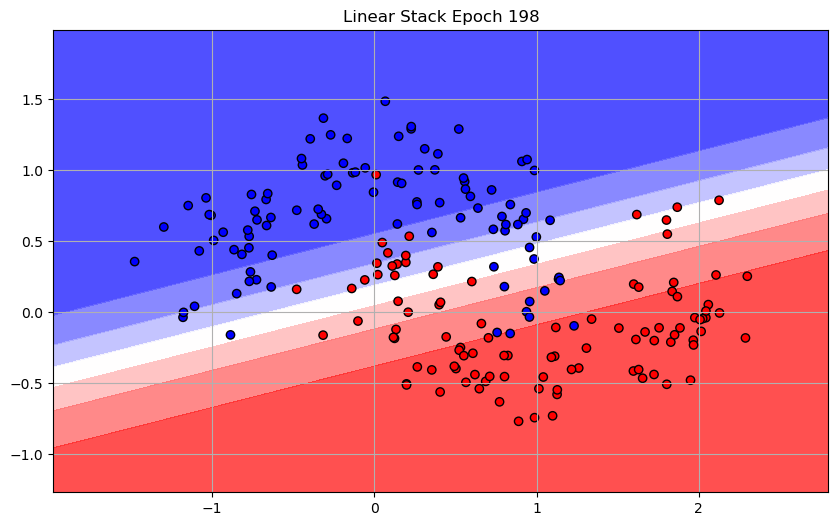

In [14]:
# Deep model WITHOUT activations
model_linear_stack = nn.Sequential(
    nn.Linear(2, 16),
    nn.Linear(16, 16),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(model_linear_stack.parameters(), lr=0.01)

# Visualization Helper for Contours
def plot_decision_map(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k')
    plt.title(title)
    plt.show()

# Train with Animation
for epoch in range(200):
    optimizer.zero_grad()
    y_pred = model_linear_stack(X_m)
    loss = criterion(y_pred, y_m)
    loss.backward()
    optimizer.step()
    
    if epoch % 2 == 0:
        clear_output(wait=True)
        plot_decision_map(model_linear_stack, X_m, y_m, f"Linear Stack Epoch {epoch}")
        plt.pause(0.1)

### Experiment 2: Adding Non-Linearity (ReLU)

Now we add `nn.ReLU()` between layers. This breaks the linearity and allows the model to "bend" the space.

Watch how the boundary curves!

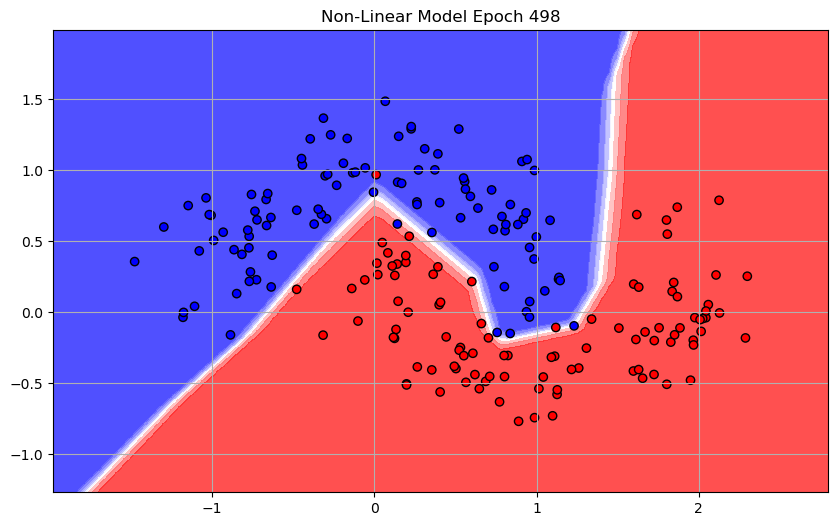

In [15]:
model_nonlinear = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),           # <-- The Magic Ingredient
    nn.Linear(16, 16),
    nn.ReLU(),           # <-- The Magic Ingredient
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(model_nonlinear.parameters(), lr=0.01)

# Train with Animation
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = model_nonlinear(X_m)
    loss = criterion(y_pred, y_m)
    loss.backward()
    optimizer.step()
    
    if epoch % 2 == 0:
        clear_output(wait=True)
        plot_decision_map(model_nonlinear, X_m, y_m, f"Non-Linear Model Epoch {epoch}")
        plt.pause(0.1)

## Part 5: Challenge (One-Hot Encoding)

In MNIST, we have 10 classes. We cannot use a single `0` or `1` output.
We need **One-Hot Encoding**.

* Class 0 -> `[1, 0, 0, 0, 0]`
* Class 1 -> `[0, 1, 0, 0, 0]`
* ...

**Your Task:** Run the code below to generate 5 blobs. Then, write code to convert the labels `y` (0, 1, 2, 3, 4) into One-Hot vectors.

In [59]:
# Generate 5 blobs
X_multi, y_multi = make_blobs(n_samples=100, centers=5, n_features=2, random_state=42)
y_multi = torch.LongTensor(y_multi) # Labels are 0, 1, 2, 3, 4

print(f"Labels sample: {y_multi[:5]}")

# --- YOUR CODE HERE ---
# Create a tensor 'y_onehot' of shape (100, 5)
# Tip: You can use torch.nn.functional.one_hot

# y_onehot = ...
# print(y_onehot[:5])

y_onehot = torch.nn.functional.one_hot(y_multi)

Labels sample: tensor([2, 4, 0, 4, 3])


In [62]:
y_multi

tensor([2, 4, 0, 4, 3, 2, 1, 1, 1, 0, 0, 2, 4, 0, 1, 3, 4, 4, 2, 3, 3, 1, 0, 2,
        3, 3, 4, 4, 4, 1, 2, 3, 4, 4, 1, 3, 0, 0, 0, 1, 2, 1, 1, 1, 3, 0, 0, 2,
        3, 4, 4, 1, 1, 2, 1, 3, 4, 4, 0, 0, 1, 0, 3, 2, 3, 2, 4, 4, 2, 4, 3, 2,
        2, 2, 4, 3, 1, 3, 4, 2, 4, 2, 3, 1, 3, 0, 3, 0, 0, 0, 3, 0, 2, 1, 2, 0,
        2, 0, 1, 1])

In [78]:
y_onehot

tensor([[0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
